# Alzheimer's MRI Classification -- MobileNetV2 (Transfer Learning)
**Dataset:** same ADNI axial MRI slices as Phase C, but with 3-channel ImageNet normalization
**Model:** MobileNetV2, pretrained on ImageNet, fine-tuned in two phases (`src/models.py`, `src/train.py`)

The key fix vs. the old (pre-project) MobileNetV2 notebook: that one **fully froze the backbone** and
never fine-tuned it at all, capping accuracy around 78% on a much easier dataset. Here: Phase 1 trains
just the new classifier head (backbone frozen), then Phase 2 unfreezes the whole model and fine-tunes
it at a much lower learning rate.

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import CLASSES, build_dataloaders, compute_class_weights
from models import build_mobilenetv2
from train import train_two_phase
from evaluate import get_predictions, slice_level_report, subject_level_report

%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, '-', torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU only')

Device: cuda - NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 2. Configuration

In [2]:
MANIFEST_PATH = '../data/manifest.csv'
CHECKPOINT_PATH = '../models/checkpoints/mobilenetv2.pt'
BATCH_SIZE = 32
FREEZE_EPOCHS = 5      # Phase 1: train head only, fixed short run
FREEZE_LR = 1e-3
UNFREEZE_EPOCHS = 25  # Phase 2: fine-tune everything, early stopping applies
UNFREEZE_LR = 1e-5      # much lower -- don't wreck the pretrained backbone
PATIENCE = 5

torch.manual_seed(42)
np.random.seed(42)

## 3. Load Dataset
Same manifest and subject-wise split as Phase C -- directly comparable results, no re-rolled split.

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)
print('Total images:', len(manifest))
print(manifest.groupby(['split', 'class']).size().unstack())

subjects_per_split = manifest.groupby('subject_id')['split'].nunique()
assert (subjects_per_split == 1).all(), 'LEAKAGE: a subject appears in more than one split!'
print('\nOK: every subject appears in exactly one split (no leakage).')

Total images: 14048
class    AD    CN  EMCI  LMCI
split                        
test    352   480   672   608
train  1728  2176  3136  2784
val     384   448   672   608

OK: every subject appears in exactly one split (no leakage).


## 4. DataLoaders + Class Weights (RGB / ImageNet-normalized this time)

In [4]:
train_loader, val_loader, test_loader = build_dataloaders(manifest, batch_size=BATCH_SIZE, rgb=True)
class_weights = compute_class_weights(manifest)

print('Batches -- train:', len(train_loader), ' val:', len(val_loader), ' test:', len(test_loader))
print('Class weights:', dict(zip(CLASSES, class_weights.tolist())))

Batches -- train: 307  val: 66  test: 66
Class weights: {'CN': 1.0710233449935913, 'AD': 1.3486961126327515, 'EMCI': 0.7431590557098389, 'LMCI': 0.8371217250823975}


## 5. Preview Sample Images

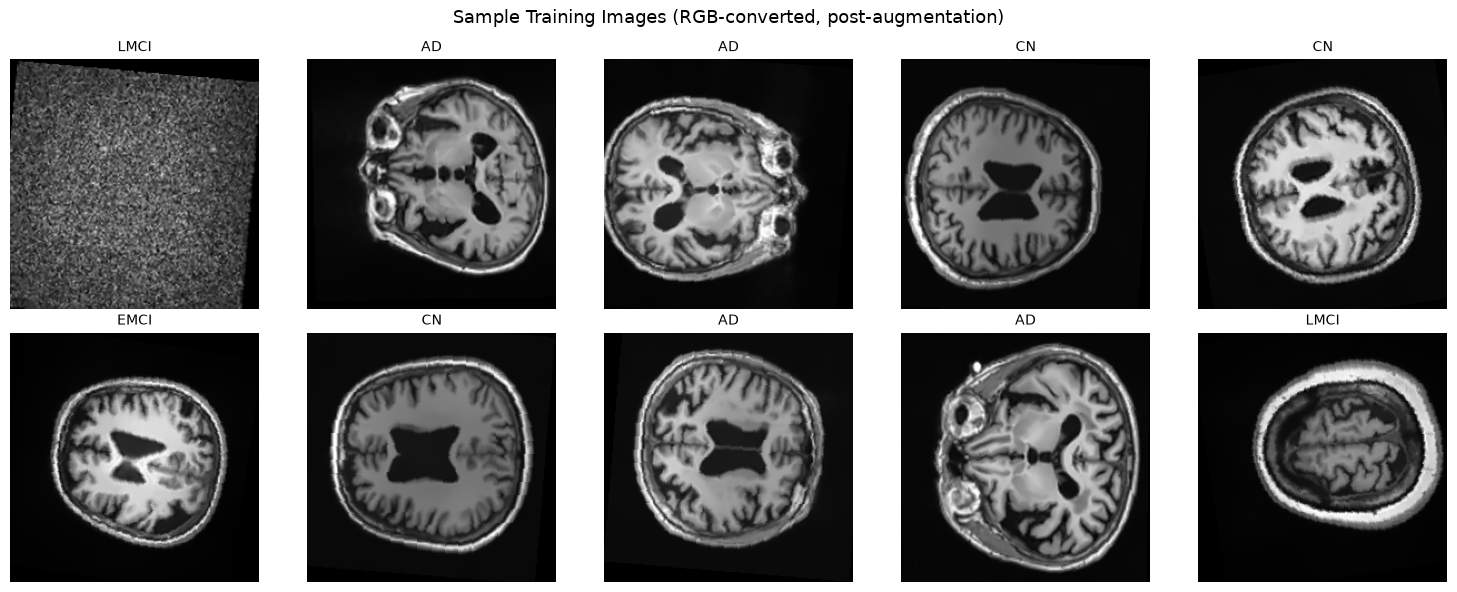

In [5]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

batch_images, batch_labels, _ = next(iter(train_loader))
display_images = (batch_images * IMAGENET_STD + IMAGENET_MEAN).clamp(0,1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(display_images[i].permute(1,2,0))
    ax.set_title(CLASSES[batch_labels[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Training Images (RGB-converted, post-augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Build Model

In [6]:
model = build_mobilenetv2(num_classes=len(CLASSES))
n_params = sum(p.numel() for p in model.parameters())
print(f'MobileNetV2: {n_params:,} total parameters (pretrained on ImageNet, head replaced for {len(CLASSES)} classes)')

MobileNetV2: 2,228,996 total parameters (pretrained on ImageNet, head replaced for 4 classes)


## 7. Train the Model (Two-Phase Fine-Tuning)
`train_two_phase` (in `src/train.py`): Phase 1 freezes the backbone and trains just the classifier head;
Phase 2 unfreezes everything and fine-tunes at a much lower learning rate, with early stopping.

In [7]:
history = train_two_phase(
    model, train_loader, val_loader, class_weights, device,
    checkpoint_path=CHECKPOINT_PATH,
    freeze_epochs=FREEZE_EPOCHS, freeze_lr=FREEZE_LR,
    unfreeze_epochs=UNFREEZE_EPOCHS, unfreeze_lr=UNFREEZE_LR, patience=PATIENCE,
)

=== Phase 1: training classifier head (backbone frozen) ===
Epoch  1/5 - train_loss 1.0648 train_acc 0.5096 - val_loss 0.9943 val_acc 0.4782
Epoch  2/5 - train_loss 0.9009 train_acc 0.5753 - val_loss 0.9285 val_acc 0.5128
Epoch  3/5 - train_loss 0.8571 train_acc 0.5908 - val_loss 0.9332 val_acc 0.5057
Epoch  4/5 - train_loss 0.8287 train_acc 0.5963 - val_loss 0.9072 val_acc 0.5099
Epoch  5/5 - train_loss 0.8177 train_acc 0.6025 - val_loss 0.9375 val_acc 0.4929

=== Phase 2: fine-tuning last 30% of backbone (BN stats adapting, weight_decay=0.0001) ===
Epoch  1/25 - train_loss 0.7788 train_acc 0.6230 - val_loss 0.8555 val_acc 0.5095
Epoch  2/25 - train_loss 0.7172 train_acc 0.6414 - val_loss 0.8260 val_acc 0.5180
Epoch  3/25 - train_loss 0.6811 train_acc 0.6578 - val_loss 0.8107 val_acc 0.5241
Epoch  4/25 - train_loss 0.6583 train_acc 0.6694 - val_loss 0.8022 val_acc 0.5322
Epoch  5/25 - train_loss 0.6360 train_acc 0.6806 - val_loss 0.8069 val_acc 0.5312
Epoch  6/25 - train_loss 0.6193 t

## 8. Training Curves
Dashed vertical line marks where Phase 2 (unfreezing) began.

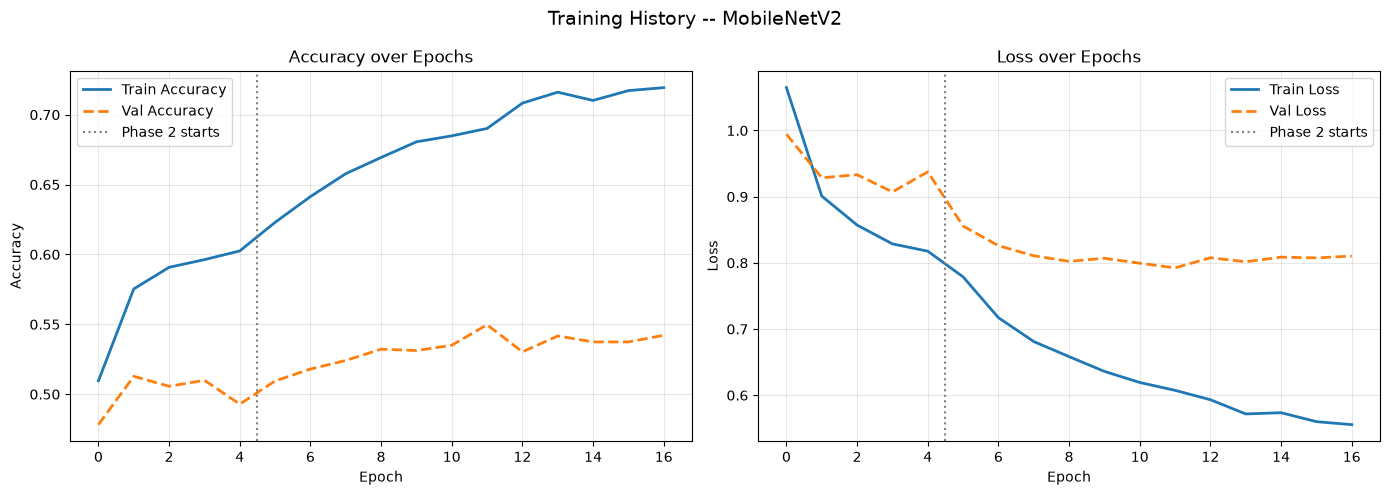

In [8]:
epochs_range = range(len(history['train_loss']))
phase1_end = history['phase1_epochs']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_acc'], label='Train Accuracy', linewidth=2)
ax1.plot(epochs_range, history['val_acc'], label='Val Accuracy', linewidth=2, linestyle='--')
ax1.axvline(phase1_end - 0.5, color='gray', linestyle=':', label='Phase 2 starts')
ax1.set_title('Accuracy over Epochs'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2)
ax2.plot(epochs_range, history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
ax2.axvline(phase1_end - 0.5, color='gray', linestyle=':', label='Phase 2 starts')
ax2.set_title('Loss over Epochs'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History -- MobileNetV2', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Evaluate on Test Set
Same two levels as Phase C: slice-level (every image separately) and subject-level (majority vote --
the number that actually matters).

In [9]:
test_preds = get_predictions(model, test_loader, device)

print('=' * 60)
print('SLICE-LEVEL classification report')
print('=' * 60)
slice_cm = slice_level_report(test_preds)

print()
print('=' * 60)
print('SUBJECT-LEVEL classification report (majority vote)')
print('=' * 60)
subject_cm, subject_preds = subject_level_report(test_preds)

SLICE-LEVEL classification report
              precision    recall  f1-score   support

          CN       0.40      0.48      0.43       480
          AD       0.27      0.48      0.34       352
        EMCI       0.54      0.34      0.42       672
        LMCI       0.56      0.43      0.48       608

    accuracy                           0.42      2112
   macro avg       0.44      0.43      0.42      2112
weighted avg       0.47      0.42      0.43      2112


SUBJECT-LEVEL classification report (majority vote)
              precision    recall  f1-score   support

          CN       0.37      0.47      0.41        15
          AD       0.20      0.36      0.26        11
        EMCI       0.56      0.24      0.33        21
        LMCI       0.61      0.58      0.59        19

    accuracy                           0.41        66
   macro avg       0.43      0.41      0.40        66
weighted avg       0.47      0.41      0.41        66



## 10. Confusion Matrices

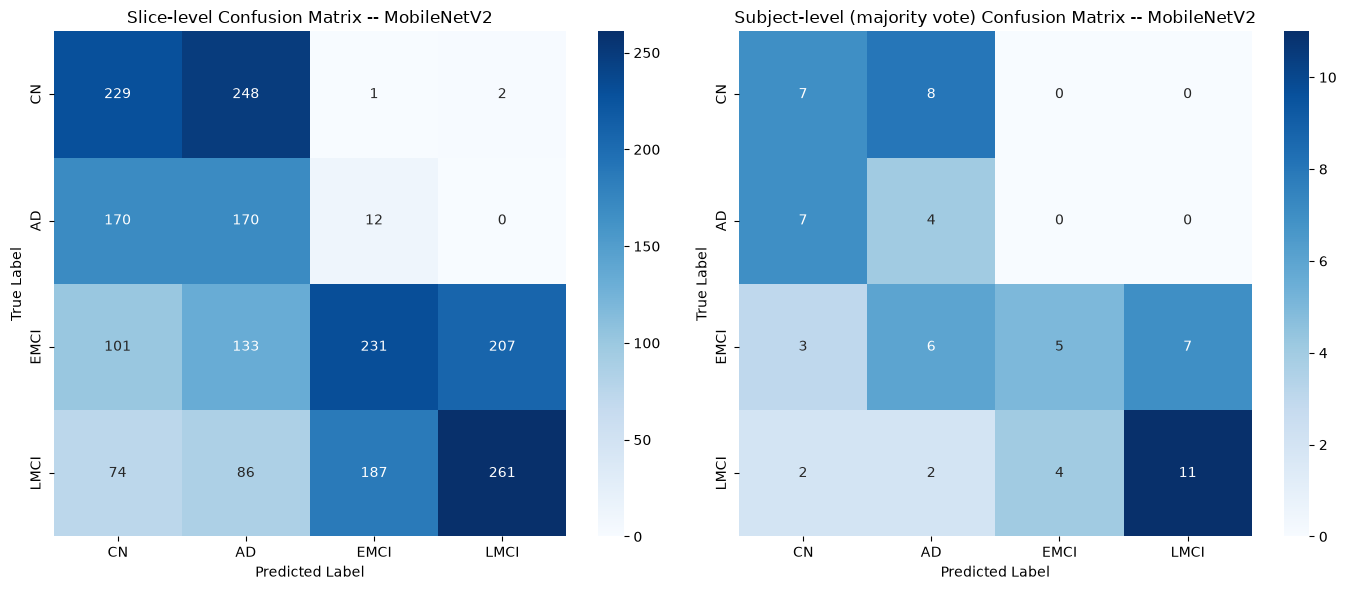

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title in [(axes[0], slice_cm, 'Slice-level'), (axes[1], subject_cm, 'Subject-level (majority vote)')]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'{title} Confusion Matrix -- MobileNetV2')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## 11. Qualitative Check: Sample Predictions

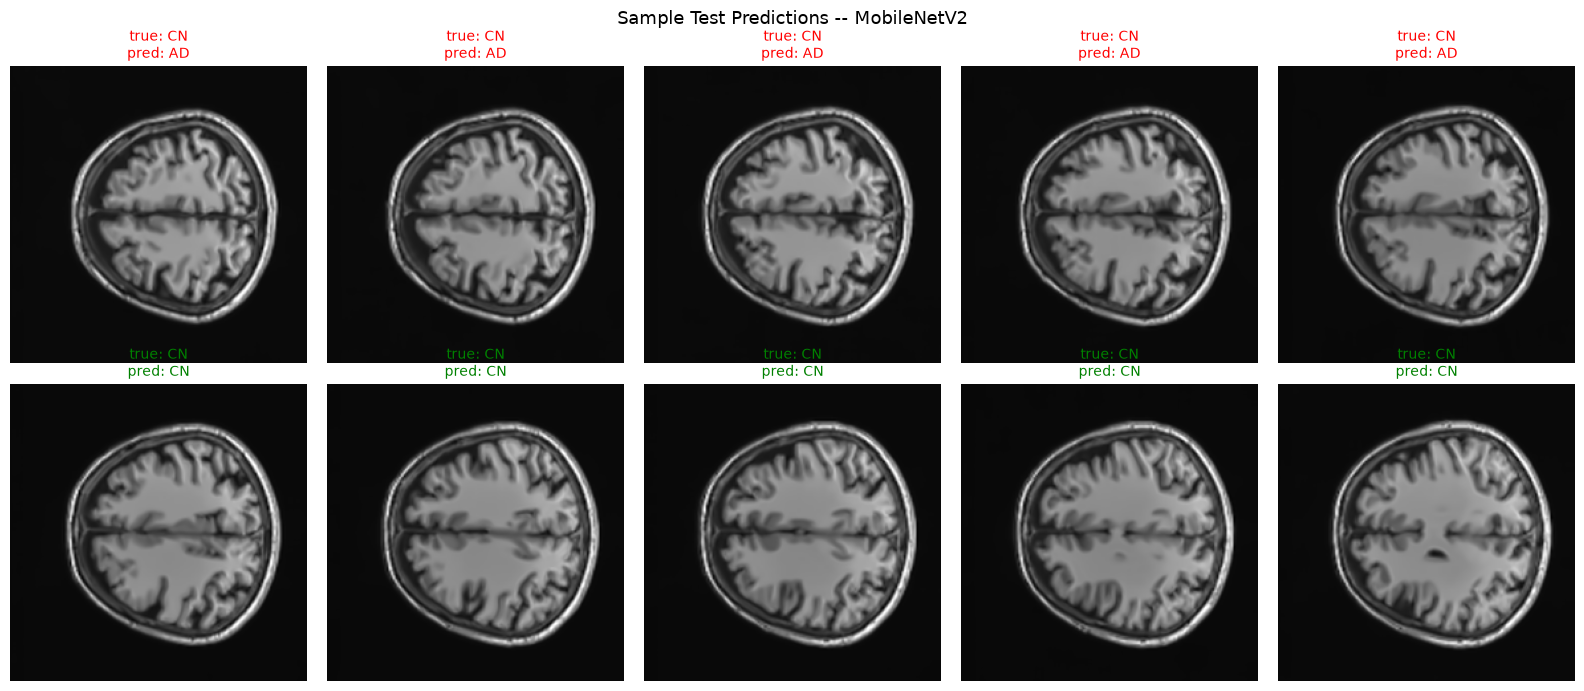

In [11]:
model.eval()
imgs, labels, subject_ids = next(iter(test_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(dim=1).cpu()

display_images = (imgs * IMAGENET_STD + IMAGENET_MEAN).clamp(0,1)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    true_label, pred_label = CLASSES[labels[i]], CLASSES[preds[i]]
    correct = true_label == pred_label
    ax.imshow(display_images[i].permute(1,2,0))
    ax.set_title(f'true: {true_label}\npred: {pred_label}', fontsize=10,
                 color='green' if correct else 'red')
    ax.axis('off')
plt.suptitle('Sample Test Predictions -- MobileNetV2', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Save Results (for the 3-model comparison table)

In [12]:
1import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score

metrics_path = Path('../reports/metrics.json')
all_metrics = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}

all_metrics['mobilenetv2'] = {
    'n_params': n_params,
    'slice_level_accuracy': accuracy_score(test_preds['true'], test_preds['pred']),
    'slice_level_macro_f1': f1_score(test_preds['true'], test_preds['pred'], average='macro'),
    'subject_level_accuracy': accuracy_score(subject_preds['true'], subject_preds['pred']),
    'subject_level_macro_f1': f1_score(subject_preds['true'], subject_preds['pred'], average='macro'),
}
metrics_path.write_text(json.dumps(all_metrics, indent=2))
print('Saved to', metrics_path.resolve())
print(json.dumps(all_metrics['mobilenetv2'], indent=2))

Saved to C:\Users\Nikunj\Documents\alzheimer-mri-project\reports\metrics.json
{
  "n_params": 2228996,
  "slice_level_accuracy": 0.421875,
  "slice_level_macro_f1": 0.4203511046302526,
  "subject_level_accuracy": 0.4090909090909091,
  "subject_level_macro_f1": 0.39943928748482826
}
